In [1]:
import numpy as np
import torch
import pymetis
import shapefile
from torch_geometric.utils import to_undirected
from data.shp_data_retrieval import get_cell_position
from data.hecras_data_retrieval import get_min_cell_elevation

# 1. Load edge_index and num_nodes from processed data (fast, no HEC-RAS needed)
constant_values_path = 'data/datasets/processed/constant_values.npz'
constant_values = np.load(constant_values_path)
edge_index = constant_values['edge_index']  # Shape: (2, num_edges)
static_nodes = constant_values['static_nodes']
num_nodes = static_nodes.shape[0]

print(f"Loaded from {constant_values_path}:")
print(f"  Nodes (with boundary placeholders): {num_nodes}")
print(f"  Edges: {edge_index.shape[1]}")

# 2. Load ALL positions from shapefile first
nodes_shp_path = 'data/datasets/raw/New_Geometry/cell_centers_with_ele.shp'
all_pos = get_cell_position(nodes_shp_path)
print(f"  All positions from shapefile (includes ghosts): {all_pos.shape}")

# 3. Identify ghost nodes (NaN elevation) the same way BoundaryCondition does
hec_ras_path = 'data/datasets/raw/HEC-RAS Results/Model_01.p22.hdf'
min_elevation = get_min_cell_elevation(hec_ras_path)
ghost_nodes = np.where(np.isnan(min_elevation))[0]
non_ghost_mask = ~np.isin(np.arange(all_pos.shape[0]), ghost_nodes)
base_pos = all_pos[non_ghost_mask]
print(f"  Ghost nodes found: {len(ghost_nodes)}")
print(f"  Positions after removing ghosts: {base_pos.shape}")

# 4. Load boundary masks to know which nodes are boundary placeholders
boundary_data_path = 'data/datasets/processed/boundary_condition_masks.npz'
boundary_data = np.load(boundary_data_path)
boundary_nodes_mask = boundary_data['boundary_nodes_mask']  # True for boundary placeholder nodes
non_boundary_mask = ~boundary_nodes_mask

# Validate counts align
if base_pos.shape[0] != non_boundary_mask.sum():
    raise ValueError(f"Non-ghost positions ({base_pos.shape[0]}) do not match non-boundary nodes ({non_boundary_mask.sum()}).")

pos_full = np.zeros((num_nodes, base_pos.shape[1]), dtype=base_pos.dtype)
non_boundary_indices = np.where(non_boundary_mask)[0]
pos_full[non_boundary_indices] = base_pos  # positions for regular nodes

# Build undirected edge_index for neighbor lookup
edge_index_torch = torch.from_numpy(edge_index).long()
edge_index_undirected = to_undirected(edge_index_torch, num_nodes=num_nodes)
edge_index_np = edge_index_undirected.numpy()

# 5. Place boundary nodes near their neighbors
boundary_indices = np.where(boundary_nodes_mask)[0]
centroid = pos_full[non_boundary_indices].mean(axis=0) if non_boundary_indices.size > 0 else np.zeros(2)
for b in boundary_indices:
    neighbor_cols = np.where((edge_index_np[0] == b) | (edge_index_np[1] == b))[0]
    neighbor_nodes = np.unique(np.concatenate([edge_index_np[0, neighbor_cols], edge_index_np[1, neighbor_cols]]))
    neighbor_nodes = neighbor_nodes[neighbor_nodes != b]
    known_neighbors = neighbor_nodes[neighbor_nodes < num_nodes]
    known_neighbors = known_neighbors[non_boundary_mask[known_neighbors]]
    if known_neighbors.size > 0:
        pos_full[b] = pos_full[known_neighbors].mean(axis=0)
    else:
        pos_full[b] = centroid

pos = pos_full
print(f"  Final position array (with boundary placeholders): {pos.shape}")

# 6. Convert to PyMetis format and partition
adj_list = [[] for _ in range(num_nodes)]
for u, v in edge_index_undirected.t().tolist():
    adj_list[u].append(v)

n_clusters = 30
print(f"\nPartitioning into {n_clusters} clusters...")
cuts, membership = pymetis.part_graph(n_clusters, adjacency=adj_list)
membership = np.array(membership)

print(f"Partitioning complete:")
print(f"  Edge cuts: {cuts}")
print(f"  Unique clusters: {len(set(membership))}")
print(f"  Nodes per cluster (avg): {num_nodes / len(set(membership)):.1f}")
print(f"  pos shape: {pos.shape}, membership len: {len(membership)}")

/Users/lincoln/Documents/UROP/flood_pi_gnn-1/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Loaded from data/datasets/processed/constant_values.npz:
  Nodes (with boundary placeholders): 1129
  Edges: 2473
  All positions from shapefile (includes ghosts): (1268, 2)
  Ghost nodes found: 142
  Positions after removing ghosts: (1126, 2)
  Final position array (with boundary placeholders): (1129, 2)

Partitioning into 30 clusters...
Partitioning complete:
  Edge cuts: 421
  Unique clusters: 30
  Nodes per cluster (avg): 37.6
  pos shape: (1129, 2), membership len: 1129


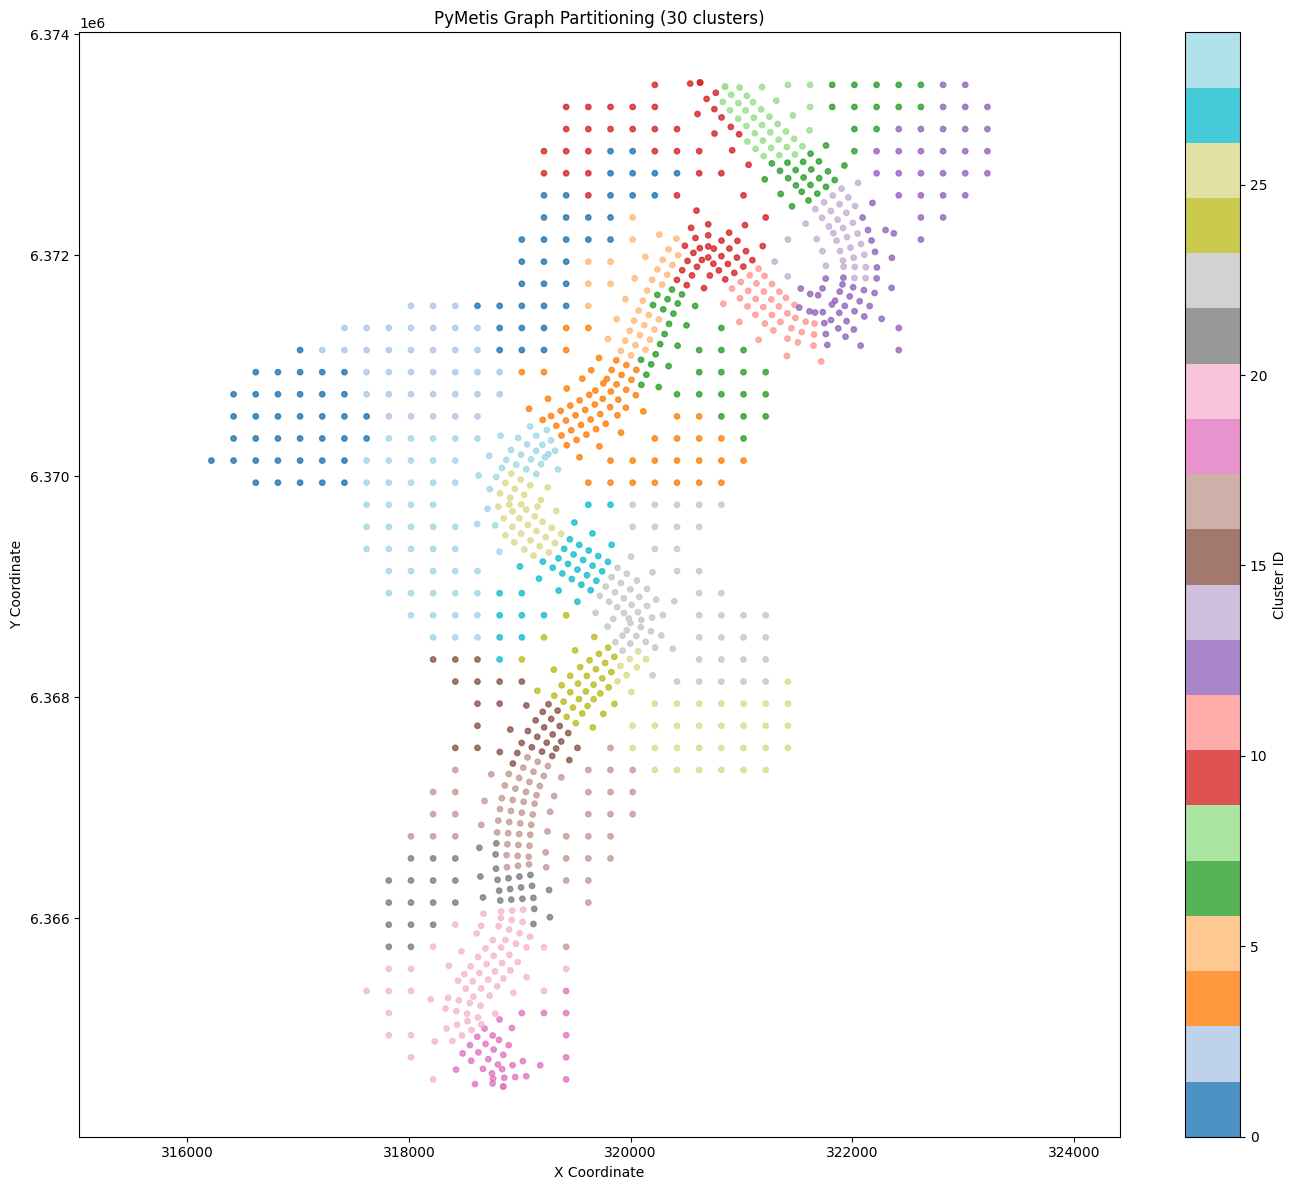

In [2]:
# 4. Visualize the partitions
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))
scatter = plt.scatter(pos[:, 0], pos[:, 1], c=membership, cmap='tab20', s=15, alpha=0.8)
plt.colorbar(scatter, label='Cluster ID')
plt.title(f'PyMetis Graph Partitioning ({n_clusters} clusters)')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.axis('equal')
plt.tight_layout()
plt.show()

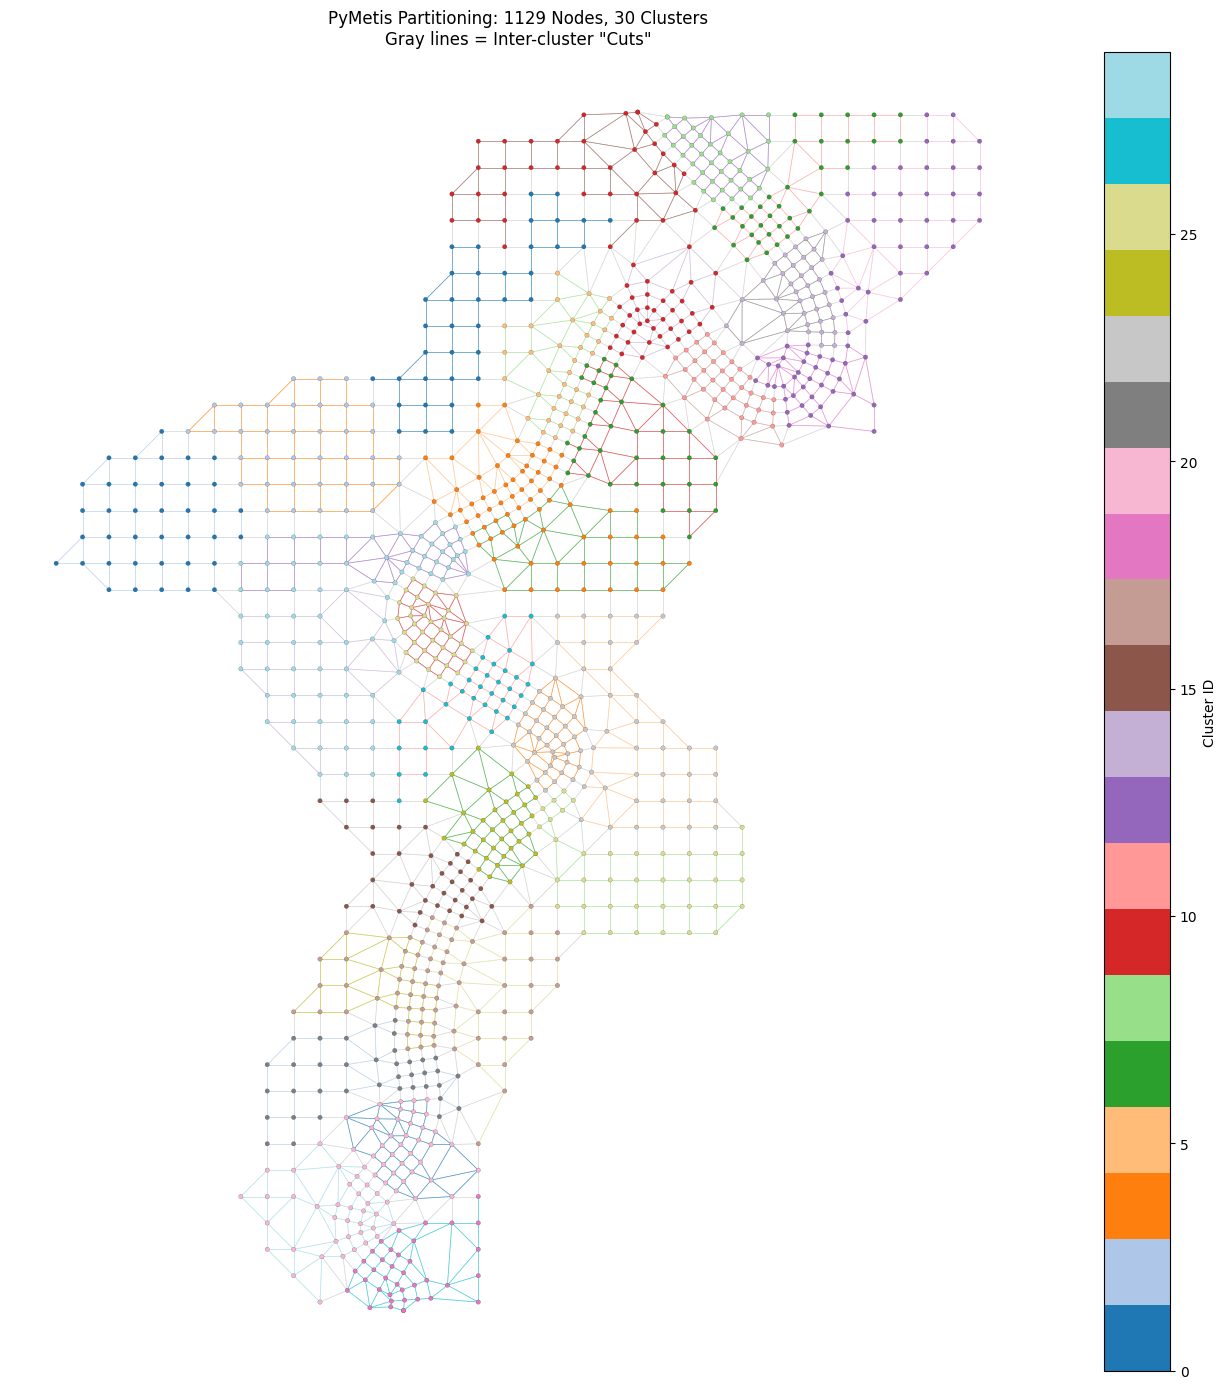

In [3]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# 1. Prepare Edge Coordinates
# edge_index_undirected is (2, num_edges)
u_idx = edge_index_undirected[0].numpy()
v_idx = edge_index_undirected[1].numpy()

# Get start and end points for every edge
start_points = pos[u_idx]
end_points = pos[v_idx]

# Create a list of lines [[(x1, y1), (x2, y2)], ...]
lines = np.stack([start_points, end_points], axis=1)

# 2. Determine Edge Colors (Optional: Highlight Cuts)
edge_membership_u = np.array(membership)[u_idx]
edge_membership_v = np.array(membership)[v_idx]

# Edges where both nodes are in the same cluster get the cluster color
# Edges that connect different clusters (cuts) will be light gray
is_cut = edge_membership_u != edge_membership_v
line_colors = plt.cm.tab20(edge_membership_u % 20) # Match node colormap
line_colors[is_cut] = [0.8, 0.8, 0.8, 0.1] # Gray and very transparent for cuts

# 3. Final Plot
fig, ax = plt.subplots(figsize=(16, 14))

# Draw Edges first (LineCollection is very fast for large graphs)
lc = LineCollection(lines, colors=line_colors, linewidths=0.5, alpha=0.5)
ax.add_collection(lc)

# Draw Nodes on top
scatter = ax.scatter(
    pos[:, 0], pos[:, 1], 
    c=membership, 
    cmap='tab20', 
    s=10, 
    zorder=3, 
    alpha=1.0, 
    edgecolors='black', 
    linewidths=0.1
)

# Formatting
plt.colorbar(scatter, label='Cluster ID', ax=ax)
ax.set_title(f'PyMetis Partitioning: {num_nodes} Nodes, {n_clusters} Clusters\nGray lines = Inter-cluster "Cuts"')
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_axis_off() # Usually looks cleaner for large graphs
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

Node 534: x=320699.625000, y=6372181.000000
Node 644: x=318905.156250, y=6369744.500000
Node 767: x=319997.968750, y=6368672.500000
Node 463: x=318919.687500, y=6366972.500000


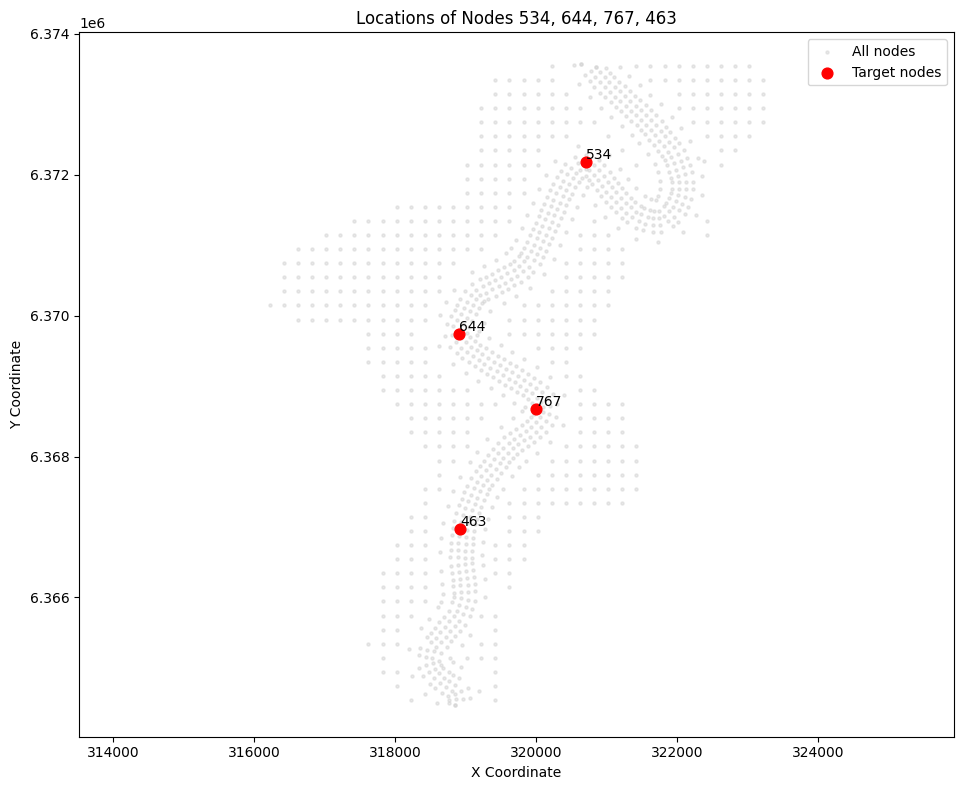

In [8]:
# Locate and plot specific nodes
import numpy as np
import matplotlib.pyplot as plt

target_nodes = np.array([534, 644, 767, 463])

# Ensure `pos` exists; if not, reconstruct using the static_nodes mapping
if 'pos' not in globals():
    constant_values = np.load('data/datasets/processed/constant_values.npz')
    static_nodes_indices = constant_values['static_nodes'].astype(int).flatten()
    from data.shp_data_retrieval import get_cell_position
    all_pos = get_cell_position('data/datasets/raw/New_Geometry/cell_centers_with_ele.shp')
    pos = all_pos[static_nodes_indices]

coords = pos[target_nodes]

for node_id, (x, y) in zip(target_nodes, coords):
    print(f"Node {node_id}: x={x:.6f}, y={y:.6f}")

# Plot all nodes in light gray for context
plt.figure(figsize=(10, 8))
plt.scatter(pos[:, 0], pos[:, 1], s=5, c='lightgray', alpha=0.5, label='All nodes')

# Highlight target nodes
plt.scatter(coords[:, 0], coords[:, 1], s=60, c='red', label='Target nodes')

# Add text labels
for node_id, (x, y) in zip(target_nodes, coords):
    plt.text(x, y, str(node_id), fontsize=10, color='black', ha='left', va='bottom')

plt.title('Locations of Nodes 534, 644, 767, 463')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.axis('equal')
plt.legend()
plt.tight_layout()
plt.show()

Node 534: x=320699.625000, y=6372181.000000
Node 644: x=318905.156250, y=6369744.500000
Node 767: x=319997.968750, y=6368672.500000
Node 463: x=318919.687500, y=6366972.500000


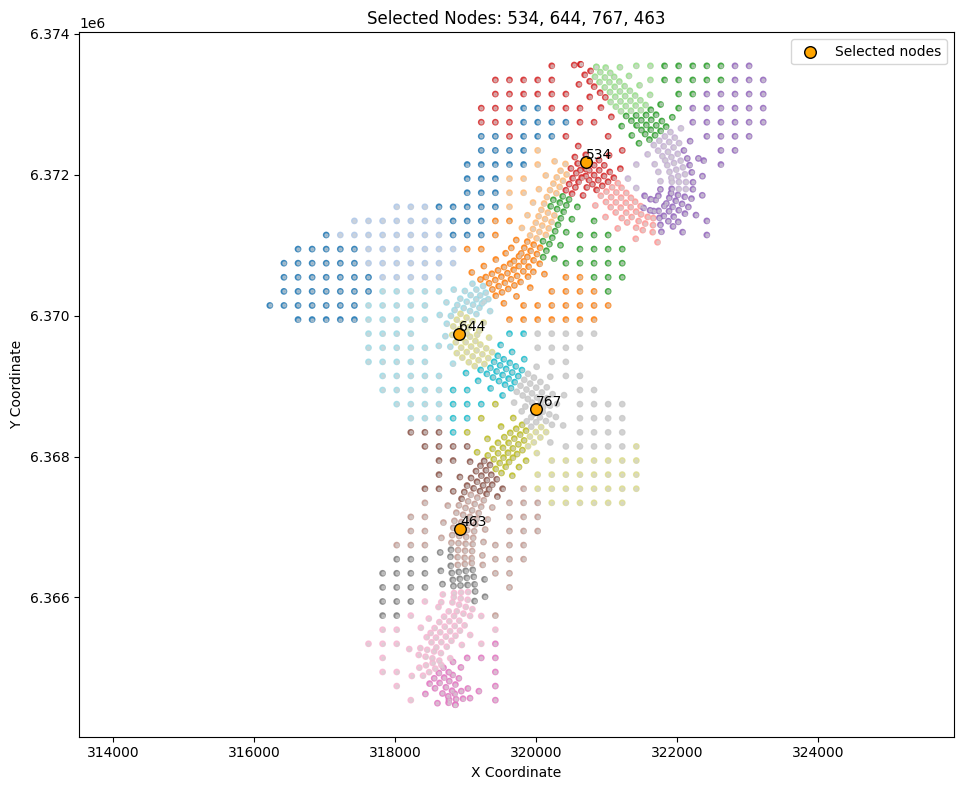

In [16]:
# Show specific nodes on the mesh
import numpy as np
import matplotlib.pyplot as plt

node_ids = np.array([534, 644, 767, 463])

# Reuse `pos` if already computed; otherwise rebuild from static_nodes mapping
# if 'pos' not in globals():
#     constant_values = np.load('data/datasets/processed/constant_values.npz')
#     static_nodes_indices = constant_values['static_nodes'].astype(int).flatten()
#     from data.shp_data_retrieval import get_cell_position
#     all_pos = get_cell_position('data/datasets/raw/New_Geometry/cell_centers_with_ele.shp')
#     pos = all_pos[static_nodes_indices]

coords = pos[node_ids]

for node_id, (x, y) in zip(node_ids, coords):
    print(f"Node {node_id}: x={x:.6f}, y={y:.6f}")

plt.figure(figsize=(10, 8))
scatter = plt.scatter(pos[:, 0], pos[:, 1], c=membership, cmap='tab20', s=15, alpha=0.8)

plt.scatter(pos[:, 0], pos[:, 1], s=5, c='lightgray', alpha=0.5)
plt.scatter(coords[:, 0], coords[:, 1], s=70, c='orange', edgecolors='black', label='Selected nodes')

for node_id, (x, y) in zip(node_ids, coords):
    plt.text(x, y, str(node_id), fontsize=10, color='black', ha='left', va='bottom')

plt.title('Selected Nodes: 534, 644, 767, 463')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.axis('equal')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
import utils.cluster_utils as cluster_utils
constant_values_path = 'data/datasets/processed/constant_values.npz'
constant_values = np.load(constant_values_path)
edge_index = constant_values['edge_index']  # must be available and match num_nodes
edge_index_torch = torch.from_numpy(edge_index).long()

static_nodes = constant_values['static_nodes']
num_nodes = static_nodes.shape[0]
partition_map = cluster_utils.partition_graph(edge_index_torch, num_nodes, 10)

cluster_groups = cluster_utils.get_centered_neighbor_groups(edge_index_torch, partition_map)
cluster_groups = cluster_utils.get_clusters_list(10, 8)

Partitioning mesh into 10 spatial clusters...


Group 0 has 8 nodes: [8, 6, 5, 3, 7, 9, 4, 1]


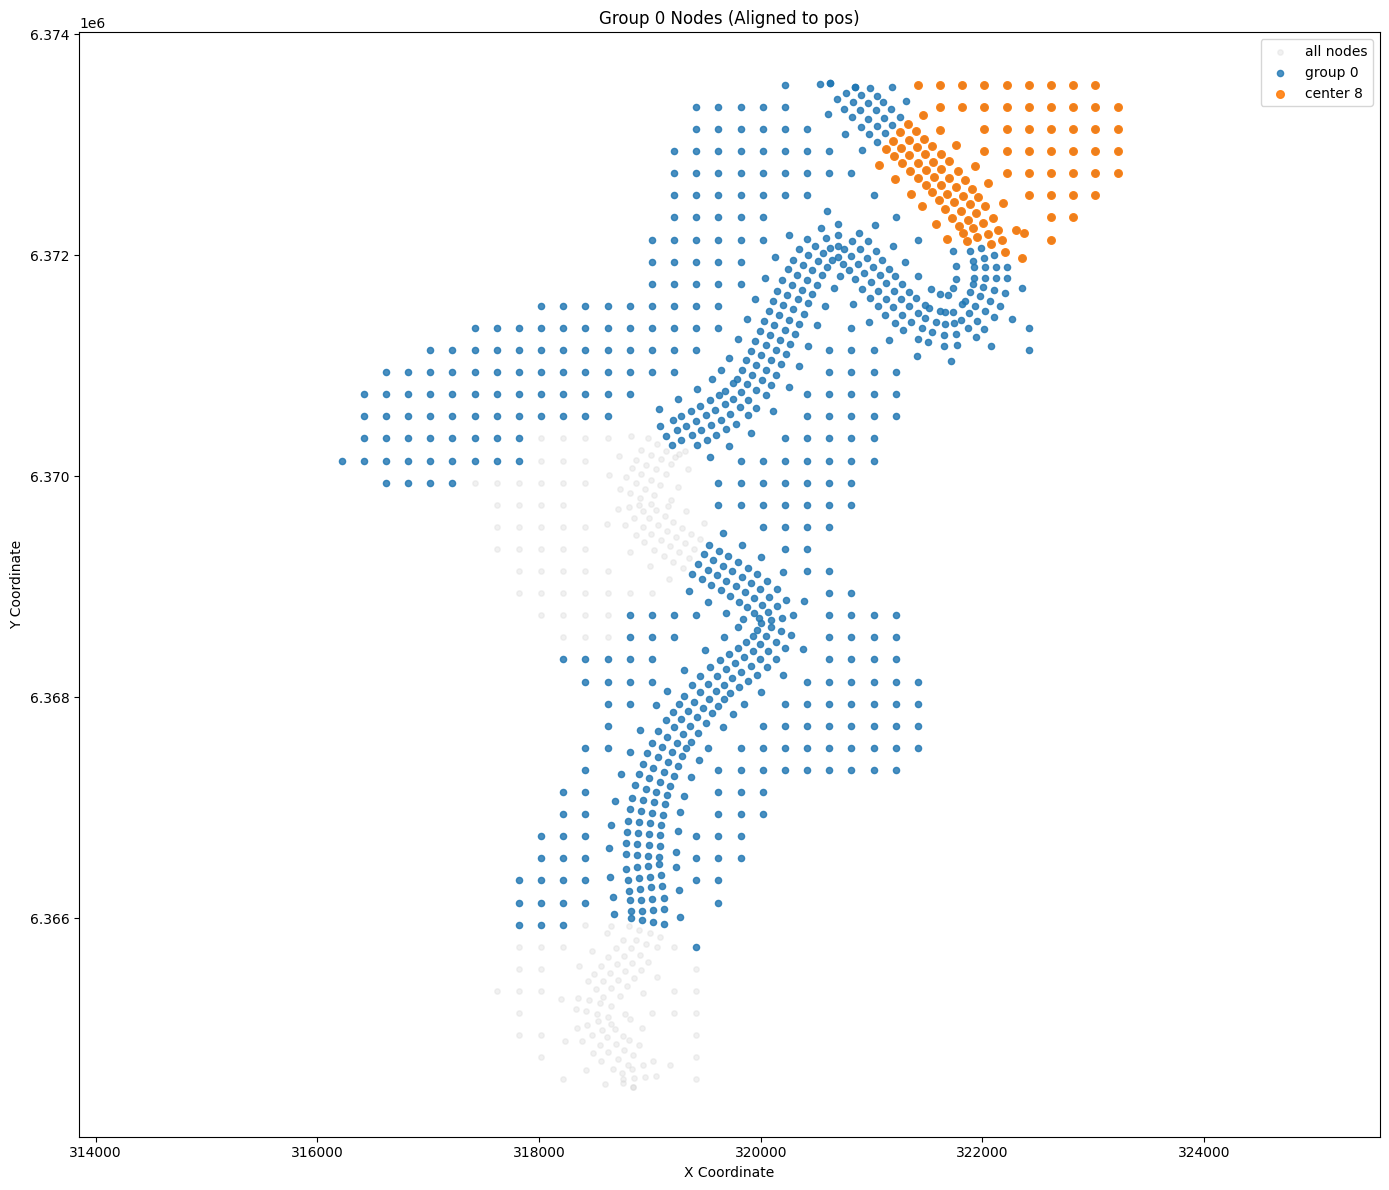

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Match the partition-plot style but highlight a single group + center cluster
group_index = 0

if "cluster_groups" not in globals() or not cluster_groups:
    raise ValueError("cluster_groups is empty. Run the group generation cell first.")
if "pos" not in globals():
    raise ValueError("pos not found. Run the position setup cell first.")

group = cluster_groups[group_index]
print(f"Group {group_index} has {len(group)} nodes: {group}")
center_cluster = group[0] if group else None
group_tensor = torch.tensor(group, device=partition_map.device)
in_group = torch.isin(partition_map, group_tensor).cpu().numpy()
is_center = (partition_map == center_cluster).cpu().numpy() if center_cluster is not None else np.zeros(len(pos), dtype=bool)

plt.figure(figsize=(14, 12))
plt.scatter(pos[:, 0], pos[:, 1], c="lightgray", s=15, alpha=0.3, label="all nodes")
plt.scatter(pos[in_group, 0], pos[in_group, 1], c="#1f77b4", s=20, alpha=0.8, label=f"group {group_index}")
if center_cluster is not None:
    plt.scatter(pos[is_center, 0], pos[is_center, 1], c="#ff7f0e", s=30, alpha=0.9, label=f"center {center_cluster}")
plt.title(f"Group {group_index} Nodes (Aligned to pos)")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.axis("equal")
plt.legend()
plt.tight_layout()
plt.show()

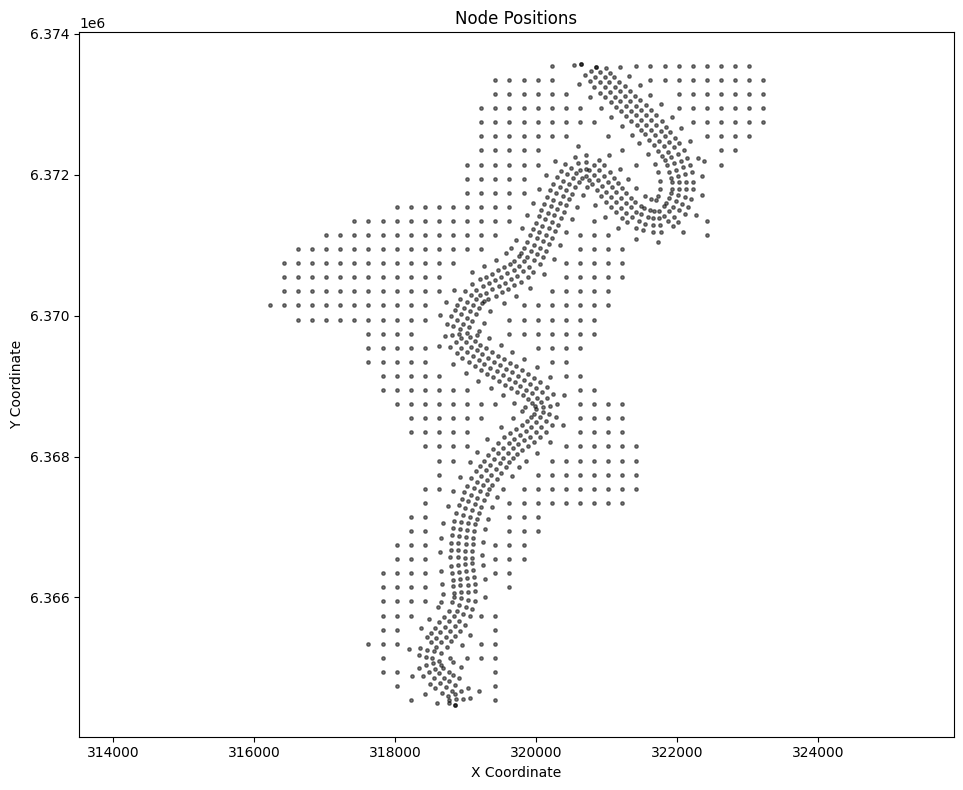

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Use computed positions if available
if "pos_arr" in globals():
    pts = np.array(pos_arr)
elif "pos" in globals():
    pts = np.array(pos)
else:
    raise ValueError("No position array found. Run the position setup cell first.")

plt.figure(figsize=(10, 8))
plt.scatter(pts[:, 0], pts[:, 1], s=6, c="black", alpha=0.5)
plt.title("Node Positions")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.axis("equal")
plt.tight_layout()
plt.show()

In [30]:
import numpy as np
import torch
from utils import cluster_utils

# Load your graph
constant_values = np.load('data/datasets/processed/constant_values.npz')
edge_index = constant_values['edge_index']
edge_index_torch = torch.from_numpy(edge_index).long()
num_nodes = constant_values['static_nodes'].shape[0]

# Partition
partition_map = cluster_utils.partition_graph(edge_index_torch, num_nodes, 10)

# Simulate both modes for 1 dataloader batch
print("=" * 90)
print("MEMORY DIAGNOSTIC: Sliding vs Non-Sliding (Single Forward/Backward Pass)")
print("=" * 90)

# Count nodes per cluster
nodes_per_cluster = []
for c in range(10):
    nodes_per_cluster.append(int((partition_map == c).sum().item()))
print(f"\nNodes per cluster: {nodes_per_cluster}")
print(f"  Min: {min(nodes_per_cluster)}, Max: {max(nodes_per_cluster)}, Avg: {np.mean(nodes_per_cluster):.1f}")

# Non-sliding mode
print("\n[NON-SLIDING MODE] clusters_per_batch=3")
non_sliding_groups = cluster_utils.get_clusters_list(10, 3)
non_sliding_node_counts = []
for group in non_sliding_groups:
    node_count = sum(nodes_per_cluster[c] for c in group)
    non_sliding_node_counts.append(node_count)
print(f"  Groups per batch: {len(non_sliding_groups)}")
print(f"  Clusters per group: {[len(g) for g in non_sliding_groups]}")
print(f"  Nodes per group: {non_sliding_node_counts}")
print(f"  Avg nodes/group: {np.mean(non_sliding_node_counts):.1f}")
print(f"  Max nodes/group: {max(non_sliding_node_counts)}")

# Sliding mode
print("\n[SLIDING MODE] center + neighbors")
sliding_groups = cluster_utils.get_centered_neighbor_groups(edge_index_torch, partition_map)
sliding_node_counts = []
for group in sliding_groups:
    node_count = sum(nodes_per_cluster[c] for c in group)
    sliding_node_counts.append(node_count)
print(f"  Groups per batch: {len(sliding_groups)}")
print(f"  Clusters per group: {[len(g) for g in sliding_groups]}")
print(f"  Nodes per group: {sliding_node_counts}")
print(f"  Avg nodes/group: {np.mean(sliding_node_counts):.1f}")
print(f"  Max nodes/group: {max(sliding_node_counts)}")

print("\n[MEMORY RATIO ESTIMATE (Peak per Single Forward/Backward Pass)]")
# Peak memory in a single pass is determined by max subgraph size
max_nodes_ratio = max(sliding_node_counts) / max(non_sliding_node_counts)
print(f"  Max nodes/group ratio (sliding/non-sliding): {max_nodes_ratio:.2f}x")

# With curr_num_timesteps in autoregressive loop, activations = nodes × timesteps
print(f"  (Assuming current_num_timesteps = 8 for example)")
print(f"  Max activations held: {max(sliding_node_counts)} × 8 = {max(sliding_node_counts)*8} node-timesteps")
print(f"  vs non-sliding: {max(non_sliding_node_counts)} × 8 = {max(non_sliding_node_counts)*8} node-timesteps")
timesteps_ratio = (max(sliding_node_counts) * 8) / (max(non_sliding_node_counts) * 8)
print(f"  Ratio: {timesteps_ratio:.2f}x")
print(f"\n  Observed memory ratio: ~4x")
print(f"  Discrepancy? Check your actual current_num_timesteps value above.")
print("=" * 90)

Partitioning mesh into 10 spatial clusters...
MEMORY DIAGNOSTIC: Sliding vs Non-Sliding (Single Forward/Backward Pass)

Nodes per cluster: [109, 110, 115, 112, 112, 110, 115, 115, 115, 116]
  Min: 109, Max: 116, Avg: 112.9

[NON-SLIDING MODE] clusters_per_batch=3
  Groups per batch: 4
  Clusters per group: [3, 3, 3, 1]
  Nodes per group: [335, 345, 334, 115]
  Avg nodes/group: 282.2
  Max nodes/group: 345

[SLIDING MODE] center + neighbors
  Groups per batch: 10
  Clusters per group: [2, 3, 5, 4, 4, 5, 5, 4, 3, 5]
  Nodes per group: [219, 331, 564, 449, 449, 568, 571, 461, 346, 571]
  Avg nodes/group: 452.9
  Max nodes/group: 571

[MEMORY RATIO ESTIMATE (Peak per Single Forward/Backward Pass)]
  Max nodes/group ratio (sliding/non-sliding): 1.66x
  (Assuming current_num_timesteps = 8 for example)
  Max activations held: 571 × 8 = 4568 node-timesteps
  vs non-sliding: 345 × 8 = 2760 node-timesteps
  Ratio: 1.66x

  Observed memory ratio: ~4x
  Discrepancy? Check your actual current_num_t

## Hypothesis: Gradient Computation Graph Complexity

The 1.65x node ratio alone doesn't explain 4x memory. The issue is likely:

1. **Autoregressive Loop Gradient Retention**: Each timestep in the `for i in range(current_num_timesteps)` loop creates intermediate tensors. When you do `total_batch_loss.backward()`, PyTorch must retain activations from ALL timesteps simultaneously.

2. **Quadratic Memory Scaling**: If larger subgraphs have more cross-node message passing, memory can scale super-linearly with node count due to edge message buffers.

3. **Possible Causes**:
   - Sliding mode might trigger longer `current_num_timesteps` via curriculum learning
   - Larger subgraphs + same timesteps = more retained activations
   - Edge count (not just node count) matters: larger subgraphs have disproportionately more edges

Let's check edge counts next:

In [31]:
import numpy as np
import torch
from utils import cluster_utils

# Reuse loaded data
constant_values = np.load('data/datasets/processed/constant_values.npz')
edge_index = constant_values['edge_index']
edge_index_torch = torch.from_numpy(edge_index).long()
num_nodes = constant_values['static_nodes'].shape[0]
partition_map = cluster_utils.partition_graph(edge_index_torch, num_nodes, 10)

print("=" * 90)
print("EDGE COUNT ANALYSIS (This is likely the key!)")
print("=" * 90)

# Helper function to count edges in a subgraph
def count_edges_in_clusters(cluster_ids, partition_map, edge_index):
    """Count edges where BOTH endpoints are in the given clusters"""
    cluster_set = set(cluster_ids)
    node_mask = torch.isin(partition_map, torch.tensor(list(cluster_set), device=partition_map.device))
    node_indices = node_mask.nonzero(as_tuple=True)[0]
    node_set = set(node_indices.tolist())
    
    edge_count = 0
    for i in range(edge_index.shape[1]):
        u, v = edge_index[0, i].item(), edge_index[1, i].item()
        if u in node_set and v in node_set:
            edge_count += 1
    return edge_count

# Non-sliding edge counts
print("\n[NON-SLIDING MODE]")
non_sliding_groups = cluster_utils.get_clusters_list(10, 3)
non_sliding_edge_counts = []
for group in non_sliding_groups:
    edge_count = count_edges_in_clusters(group, partition_map, edge_index_torch)
    non_sliding_edge_counts.append(edge_count)
print(f"  Edges per group: {non_sliding_edge_counts}")
print(f"  Max edges/group: {max(non_sliding_edge_counts)}")
print(f"  Avg edges/group: {np.mean(non_sliding_edge_counts):.1f}")

# Sliding edge counts
print("\n[SLIDING MODE]")
sliding_groups = cluster_utils.get_centered_neighbor_groups(edge_index_torch, partition_map)
sliding_edge_counts = []
for group in sliding_groups:
    edge_count = count_edges_in_clusters(group, partition_map, edge_index_torch)
    sliding_edge_counts.append(edge_count)
print(f"  Edges per group: {sliding_edge_counts}")
print(f"  Max edges/group: {max(sliding_edge_counts)}")
print(f"  Avg edges/group: {np.mean(sliding_edge_counts):.1f}")

print("\n[EDGE RATIO (GNN Memory Scales with Edge Count!)]")
edge_ratio = max(sliding_edge_counts) / max(non_sliding_edge_counts)
print(f"  Max edges ratio (sliding/non-sliding): {edge_ratio:.2f}x")
print(f"\n  Combined factors:")
print(f"    Node ratio: 1.65x")
print(f"    Edge ratio: {edge_ratio:.2f}x")
print(f"    → GNN message passing scales with edges, NOT just nodes!")
print(f"    → If edge_ratio ≈ 2.4x combined with node features ≈ 1.65x,")
print(f"       total memory could reach ~4x due to edge message buffers")
print("=" * 90)

Partitioning mesh into 10 spatial clusters...
EDGE COUNT ANALYSIS (This is likely the key!)

[NON-SLIDING MODE]
  Edges per group: [701, 704, 702, 237]
  Max edges/group: 704
  Avg edges/group: 586.0

[SLIDING MODE]
  Edges per group: [483, 734, 1204, 969, 972, 1194, 1217, 969, 748, 1217]
  Max edges/group: 1217
  Avg edges/group: 970.7

[EDGE RATIO (GNN Memory Scales with Edge Count!)]
  Max edges ratio (sliding/non-sliding): 1.73x

  Combined factors:
    Node ratio: 1.65x
    Edge ratio: 1.73x
    → GNN message passing scales with edges, NOT just nodes!
    → If edge_ratio ≈ 2.4x combined with node features ≈ 1.65x,
       total memory could reach ~4x due to edge message buffers


Node 534: x=320699.625000, y=6372181.000000
Node 644: x=318905.156250, y=6369744.500000
Node 767: x=319997.968750, y=6368672.500000
Node 463: x=318919.687500, y=6366972.500000


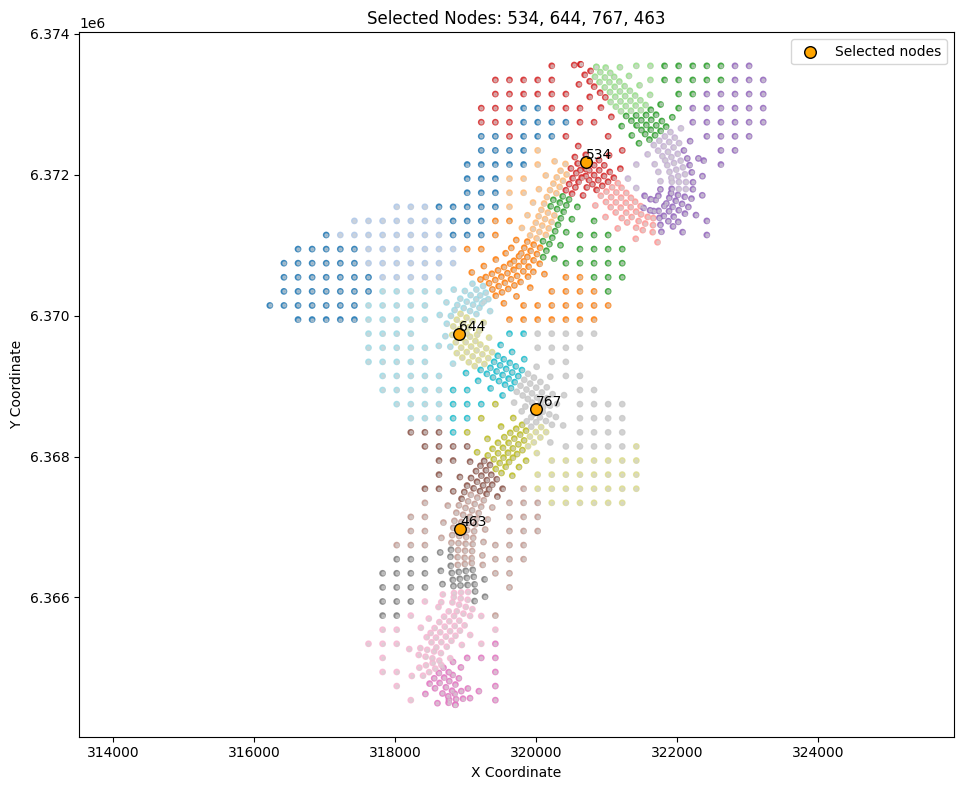

In [32]:
# Show specific nodes on the mesh
import numpy as np
import matplotlib.pyplot as plt

node_ids = np.array([534, 644, 767, 463])

# Reuse `pos` if already computed; otherwise rebuild from static_nodes mapping
# if 'pos' not in globals():
#     constant_values = np.load('data/datasets/processed/constant_values.npz')
#     static_nodes_indices = constant_values['static_nodes'].astype(int).flatten()
#     from data.shp_data_retrieval import get_cell_position
#     all_pos = get_cell_position('data/datasets/raw/New_Geometry/cell_centers_with_ele.shp')
#     pos = all_pos[static_nodes_indices]

coords = pos[node_ids]

for node_id, (x, y) in zip(node_ids, coords):
    print(f"Node {node_id}: x={x:.6f}, y={y:.6f}")

plt.figure(figsize=(10, 8))
scatter = plt.scatter(pos[:, 0], pos[:, 1], c=membership, cmap='tab20', s=15, alpha=0.8)

plt.scatter(pos[:, 0], pos[:, 1], s=5, c='lightgray', alpha=0.5)
plt.scatter(coords[:, 0], coords[:, 1], s=70, c='orange', edgecolors='black', label='Selected nodes')

for node_id, (x, y) in zip(node_ids, coords):
    plt.text(x, y, str(node_id), fontsize=10, color='black', ha='left', va='bottom')

plt.title('Selected Nodes: 534, 644, 767, 463')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.axis('equal')
plt.legend()
plt.tight_layout()
plt.show()